# 2. Segunda base de datos. PAMAP 2

## 2.1. Cargar datos

In [1]:
import pandas as pd
import os

In [3]:
pd.set_option("display.float_format", "{:.3f}".format)

In [5]:
from abc import ABC, abstractmethod

class AbstractDataLoader(ABC):
    def __init__(self, src_path:str, keys:list, file_extension:str, delimiter:str):
        self.src_path = src_path
        self.keys = keys
        self.file_extension = file_extension
        self.delimiter = delimiter     
        
    @abstractmethod
    def load_data(self):
        pass

    @abstractmethod
    def _is_valid_extension(self, file):
        pass

In [7]:
class DataLoader(AbstractDataLoader):
    def __init__(self, src_path:str, keys:list, file_extension:str, delimiter:str):
        super().__init__(src_path, keys, file_extension, delimiter)
        
    
    def load_data(self):
        dataframes = []
        for file in os.listdir(self.src_path):
            if self._is_valid_extension(file):  
                df = pd.read_csv(os.path.join(self.src_path, file), delimiter=self.delimiter, names=self.keys)
                df['subject_id'] = self._get_subject_id(file)
                dataframes.append(df)
        final_df = pd.concat(dataframes, ignore_index=True)
        return final_df

                
    def _is_valid_extension(self, file):
        return file.endswith(self.file_extension)

    def _get_subject_id(self, file):
        return file.split('.')[0]

In [9]:
src = "datasets/2_PAMAP2/PAMAP2_Dataset/Protocol/"
keys = [
    "timestamp",
    "activityID",
    "heart_rate_bpm",
    # IMU Hand (columns 4–20)
    "IMU_Hand_temperature",
    "IMU_Hand_acceleration_16g_x",
    "IMU_Hand_acceleration_16g_y",
    "IMU_Hand_acceleration_16g_z",
    "IMU_Hand_acceleration_6g_x",
    "IMU_Hand_acceleration_6g_y",
    "IMU_Hand_acceleration_6g_z",
    "IMU_Hand_gyroscope_x",
    "IMU_Hand_gyroscope_y",
    "IMU_Hand_gyroscope_z",
    "IMU_Hand_magnetometer_x",
    "IMU_Hand_magnetometer_y",
    "IMU_Hand_magnetometer_z",
    "IMU_Hand_orientation_1",
    "IMU_Hand_orientation_2",
    "IMU_Hand_orientation_3",
    "IMU_Hand_orientation_4",
    # IMU Chest (columns 21–37)
    "IMU_Chest_temperature",
    "IMU_Chest_acceleration_16g_x",
    "IMU_Chest_acceleration_16g_y",
    "IMU_Chest_acceleration_16g_z",
    "IMU_Chest_acceleration_6g_x",
    "IMU_Chest_acceleration_6g_y",
    "IMU_Chest_acceleration_6g_z",
    "IMU_Chest_gyroscope_x",
    "IMU_Chest_gyroscope_y",
    "IMU_Chest_gyroscope_z",
    "IMU_Chest_magnetometer_x",
    "IMU_Chest_magnetometer_y",
    "IMU_Chest_magnetometer_z",
    "IMU_Chest_orientation_1",
    "IMU_Chest_orientation_2",
    "IMU_Chest_orientation_3",
    "IMU_Chest_orientation_4",
    # IMU Ankle (columns 38–54)
    "IMU_Ankle_temperature",
    "IMU_Ankle_acceleration_16g_x",
    "IMU_Ankle_acceleration_16g_y",
    "IMU_Ankle_acceleration_16g_z",
    "IMU_Ankle_acceleration_6g_x",
    "IMU_Ankle_acceleration_6g_y",
    "IMU_Ankle_acceleration_6g_z",
    "IMU_Ankle_gyroscope_x",
    "IMU_Ankle_gyroscope_y",
    "IMU_Ankle_gyroscope_z",
    "IMU_Ankle_magnetometer_x",
    "IMU_Ankle_magnetometer_y",
    "IMU_Ankle_magnetometer_z",
    "IMU_Ankle_orientation_1",
    "IMU_Ankle_orientation_2",
    "IMU_Ankle_orientation_3",
    "IMU_Ankle_orientation_4"
]

file_extension = '.dat'
delimiter = r'\s+'
data_loader_pamap = DataLoader(src, keys, file_extension, delimiter)
pamap_data = data_loader_pamap.load_data()

pamap_data.shape

(2872533, 55)

## Missing values

In [15]:
pamap_data.isnull().sum()

timestamp                             0
activityID                            0
heart_rate_bpm                  2610265
IMU_Hand_temperature              13141
IMU_Hand_acceleration_16g_x       13141
IMU_Hand_acceleration_16g_y       13141
IMU_Hand_acceleration_16g_z       13141
IMU_Hand_acceleration_6g_x        13141
IMU_Hand_acceleration_6g_y        13141
IMU_Hand_acceleration_6g_z        13141
IMU_Hand_gyroscope_x              13141
IMU_Hand_gyroscope_y              13141
IMU_Hand_gyroscope_z              13141
IMU_Hand_magnetometer_x           13141
IMU_Hand_magnetometer_y           13141
IMU_Hand_magnetometer_z           13141
IMU_Hand_orientation_1            13141
IMU_Hand_orientation_2            13141
IMU_Hand_orientation_3            13141
IMU_Hand_orientation_4            13141
IMU_Chest_temperature              3563
IMU_Chest_acceleration_16g_x       3563
IMU_Chest_acceleration_16g_y       3563
IMU_Chest_acceleration_16g_z       3563
IMU_Chest_acceleration_6g_x        3563


In [25]:
unique_activity_ids = pamap_data['activityID'].unique()
unique_activity_ids_sorted = np.sort(unique_activity_ids)
unique_activity_ids_sorted

array([ 0,  1,  2,  3,  4,  5,  6,  7, 12, 13, 16, 17, 24], dtype=int64)

In [37]:
import numpy as np

activity_counts = pamap_data['activityID'].value_counts().sort_index()
activity_counts

activityID
0     929661
1     192523
2     185188
3     189931
4     238761
5      98199
6     164600
7     188107
12    117216
13    104944
16    175353
17    238690
24     49360
Name: count, dtype: int64

Se han eliminado filas con valores faltantes. Nuevo shape: (259803, 55)


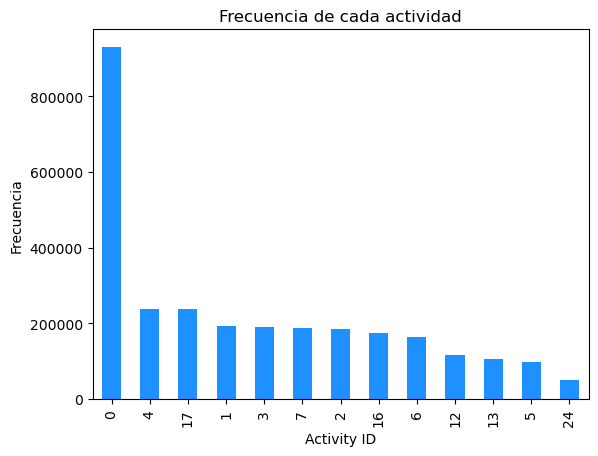

In [53]:
import matplotlib.pyplot as plt

activity_counts = pamap_data['activityID'].value_counts().sort_values(ascending=False)

activity_counts.plot(kind='bar', color='dodgerblue')

plt.xlabel('Activity ID')
plt.ylabel('Frecuencia')
plt.title('Frecuencia de cada actividad')

df_clean = pamap_data.dropna()
print("Se han eliminado filas con valores faltantes. Nuevo shape:", df_clean.shape)


In [31]:
df_clean = pamap_data.dropna()
df_clean.shape

(259803, 55)

In [41]:
activity_counts = df_clean['activityID'].value_counts().sort_index()
activity_counts

activityID
0     84305
1     17575
2     16881
3     17256
4     20998
5      8665
6     14933
7     16857
12    10699
13     9585
16    15997
17    21696
24     4356
Name: count, dtype: int64

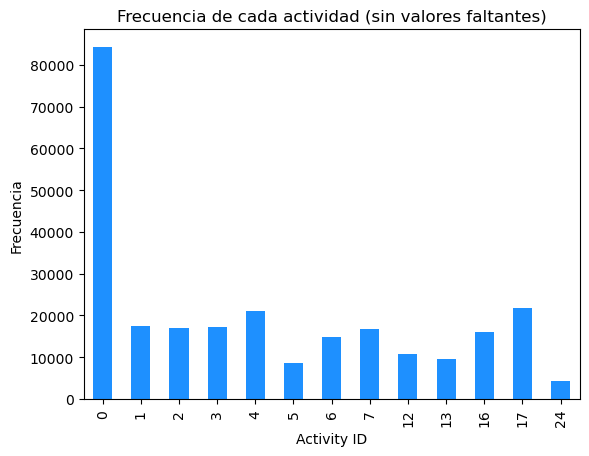

In [51]:
import matplotlib.pyplot as plt

# Create the bar plot using "dodgerblue" as the color
activity_counts.plot(kind='bar', color='dodgerblue')
plt.xlabel('Activity ID')
plt.ylabel('Frecuencia')
plt.title('Frecuencia de cada actividad (sin valores faltantes)')
plt.show()



# Hay alguna diferencia?

## 1. En tamaño

In [45]:
import pandas as pd

# Frecuencias antes de eliminar filas con NA
freq_antes = pamap_data['activityID'].value_counts().sort_index()

# Creamos el DataFrame limpio (con listwise deletion)
df_clean = pamap_data.dropna()

# Frecuencias después de eliminar filas con NA
freq_despues = df_clean['activityID'].value_counts().sort_index()

# Creamos un DataFrame combinando ambas series
tabla = pd.DataFrame({
    'Antes de eliminar': freq_antes,
    'Después de eliminar': freq_despues
})

# Si alguna actividad no aparece en el DataFrame limpio, rellenamos con 0
tabla.fillna(0, inplace=True)

# Calculamos el porcentaje de ejemplos perdidos por actividad
tabla['Porcentaje perdido (%)'] = ((tabla['Antes de eliminar'] - tabla['Después de eliminar']) / tabla['Antes de eliminar'] * 100).round(2)

# Asignamos nombre al índice para indicar que es el id de la actividad
tabla.index.name = 'ID actividad'

tabla

,Antes de eliminar,Después de eliminar,Porcentaje perdido (%)
ID actividad,,,
0,929661,84305,90.930
1,192523,17575,90.870
2,185188,16881,90.880
3,189931,17256,90.910
4,238761,20998,91.210
5,98199,8665,91.180
6,164600,14933,90.930
7,188107,16857,91.040
12,117216,10699,90.870


In [59]:
mean_loss = tabla['Porcentaje perdido (%)'].mean()
print("El promedio de información perdida es: {:.2f}%".format(mean_loss))

El promedio de información perdida es: 90.97%


In [63]:
from scipy.stats import ks_2samp
import pandas as pd

# Definir las columnas de sensores (excluyendo 'timestamp' y 'activityID')
sensor_columns = [col for col in pamap_data.columns if col not in ['timestamp', 'activityID']]

# Lista para almacenar los resultados
ks_results = []

for sensor in sensor_columns:
    # Extraemos los datos originales (con dropna local, para esa columna) y los datos limpios (ya sin filas con NA)
    data_original = pamap_data[sensor].dropna()
    data_clean = df_clean[sensor]
    
    # Aplicamos la prueba KS
    ks_stat, p_val = ks_2samp(data_original, data_clean)
    
    # Interpretamos el p-value
    interpretation = "Cambio significativo" if p_val < 0.05 else "Sin cambio significativo"
    
    ks_results.append({
        "Sensor": sensor,
        "KS Statistic": ks_stat,
        "p-value": p_val,
        "Interpretación": interpretation
    })

# Convertimos los resultados a un DataFrame
ks_results_df = pd.DataFrame(ks_results)

print("Resultados de la prueba KS para cada sensor:")
ks_results_df

Resultados de la prueba KS para cada sensor:


,Sensor,KS Statistic,p-value,Interpretación
0,heart_rate_bpm,0.002,0.415,Sin cambio significativo
1,IMU_Hand_temperature,0.001,0.887,Sin cambio significativo
2,IMU_Hand_acceleration_16g_x,0.001,0.998,Sin cambio significativo
3,IMU_Hand_acceleration_16g_y,0.001,0.999,Sin cambio significativo
4,IMU_Hand_acceleration_16g_z,0.001,0.992,Sin cambio significativo
5,IMU_Hand_acceleration_6g_x,0.001,0.986,Sin cambio significativo
6,IMU_Hand_acceleration_6g_y,0.001,0.985,Sin cambio significativo
7,IMU_Hand_acceleration_6g_z,0.001,0.956,Sin cambio significativo
8,IMU_Hand_gyroscope_x,0.001,0.991,Sin cambio significativo
9,IMU_Hand_gyroscope_y,0.001,0.982,Sin cambio significativo


In [71]:
from scipy.stats import chisquare
import pandas as pd

# Frecuencias en el conjunto original y en el limpio, ordenadas por ID
freq_original = pamap_data['activityID'].value_counts().sort_index()
freq_clean = df_clean['activityID'].value_counts().sort_index()

# Reescalamos las frecuencias originales al tamaño del conjunto limpio
expected = freq_original * (df_clean.shape[0] / pamap_data.shape[0])

# Realizamos la prueba chi-cuadrado
chi2_stat, p_val = chisquare(f_obs=freq_clean, f_exp=expected)

interpretacion = "Cambio significativo" if p_val < 0.05 else "Sin cambio significativo"

chi2_summary = pd.DataFrame({
    "Chi2 Statistic": [chi2_stat],
    "p-value": [p_val],
    "Interpretación": [interpretacion]
})

print("Resultados del test Chi-Cuadrado para 'activityID':")
chi2_summary

Resultados del test Chi-Cuadrado para 'activityID':


,Chi2 Statistic,p-value,Interpretación
0,33.001,0.001,Cambio significativo


In [75]:
import pandas as pd
import numpy as np

# Frecuencias originales (antes de eliminar) y después de eliminar, ordenadas por activityID
freq_antes = pamap_data['activityID'].value_counts().sort_index()
freq_despues = df_clean['activityID'].value_counts().sort_index()

# Creamos un DataFrame con las frecuencias; rellenamos con 0 donde falten actividades
tabla_chi = pd.DataFrame({
    'Antes': freq_antes,
    'Después': freq_despues
}).fillna(0)

# Calculamos la frecuencia esperada para el conjunto limpio
tabla_chi['Expected'] = tabla_chi['Antes'] * (df_clean.shape[0] / pamap_data.shape[0])

# Calculamos la contribución individual al estadístico chi: (O - E)^2 / E
tabla_chi['Chi Contribution'] = ((tabla_chi['Después'] - tabla_chi['Expected']) ** 2) / tabla_chi['Expected']

# Calculamos los residuos estandarizados: (O - E) / sqrt(E)
tabla_chi['Standardized Residual'] = (tabla_chi['Después'] - tabla_chi['Expected']) / np.sqrt(tabla_chi['Expected'])

# Agregamos una columna de interpretación basada en los residuos estandarizados
tabla_chi['Interpretación'] = tabla_chi['Standardized Residual'].apply(
    lambda x: "Cambio significativo" if abs(x) > 2 else "Sin cambio significativo"
)

# Asignamos nombre al índice para indicar que es el ID de la actividad
tabla_chi.index.name = 'ID actividad'

print("Tabla de contribuciones y residuos estandarizados:")
tabla_chi

Tabla de contribuciones y residuos estandarizados:


,Antes,Después,Expected,Chi Contribution,Standardized Residual,Interpretación
ID actividad,,,,,,
0,929661,84305,84082.138,0.591,0.769,Sin cambio significativo
1,192523,17575,17412.525,1.516,1.231,Sin cambio significativo
2,185188,16881,16749.119,1.038,1.019,Sin cambio significativo
3,189931,17256,17178.095,0.353,0.594,Sin cambio significativo
4,238761,20998,21594.469,16.475,-4.059,Cambio significativo
5,98199,8665,8881.498,5.277,-2.297,Cambio significativo
6,164600,14933,14887.061,0.142,0.377,Sin cambio significativo
7,188107,16857,17013.125,1.433,-1.197,Sin cambio significativo
12,117216,10699,10601.469,0.897,0.947,Sin cambio significativo


In [81]:
from scipy.stats import f
import numpy as np
import pandas as pd

# Definir las columnas de sensores (excluyendo 'timestamp' y 'activityID')
sensor_columns = [col for col in pamap_data.columns if col not in ['timestamp', 'activityID']]

f_results = []

for sensor in sensor_columns:
    # Convertir a numérico, convirtiendo errores en NaN y luego descartarlos
    data_orig = pd.to_numeric(pamap_data[sensor], errors='coerce').dropna()
    data_clean = pd.to_numeric(df_clean[sensor], errors='coerce').dropna()
    
    # Asegurarnos de tener suficientes datos para calcular la varianza
    if len(data_orig) < 2 or len(data_clean) < 2:
        continue
    
    # Calcular varianzas muestrales (con ddof=1)
    var_orig = np.var(data_orig, ddof=1)
    var_clean = np.var(data_clean, ddof=1)
    
    n_orig = len(data_orig)
    n_clean = len(data_clean)
    
    # Colocar la mayor varianza en el numerador
    if var_orig >= var_clean:
        F_value = var_orig / var_clean
        dfn = n_orig - 1  # grados de libertad numerador
        dfd = n_clean - 1  # grados de libertad denominador
    else:
        F_value = var_clean / var_orig
        dfn = n_clean - 1
        dfd = n_orig - 1

    # Calcular el p-value para el test de dos colas
    p_val = 2 * min(f.cdf(F_value, dfn, dfd), 1 - f.cdf(F_value, dfn, dfd))
    
    interpretation = "Cambio significativo" if p_val < 0.05 else "Sin cambio significativo"
    
    f_results.append({
        "Sensor": sensor,
        "F-value": F_value,
        "p-value": p_val,
        "Interpretación": interpretation
    })

f_results_df = pd.DataFrame(f_results)

print("Resultados del test F (varianzas) para cada sensor:")
f_results_df


Resultados del test F (varianzas) para cada sensor:


,Sensor,F-value,p-value,Interpretación
0,heart_rate_bpm,1.002,0.679,Sin cambio significativo
1,IMU_Hand_temperature,1.002,0.602,Sin cambio significativo
2,IMU_Hand_acceleration_16g_x,1.005,0.079,Sin cambio significativo
3,IMU_Hand_acceleration_16g_y,1.017,0.000,Cambio significativo
4,IMU_Hand_acceleration_16g_z,1.003,0.265,Sin cambio significativo
5,IMU_Hand_acceleration_6g_x,1.004,0.225,Sin cambio significativo
6,IMU_Hand_acceleration_6g_y,1.003,0.330,Sin cambio significativo
7,IMU_Hand_acceleration_6g_z,1.001,0.783,Sin cambio significativo
8,IMU_Hand_gyroscope_x,1.001,0.820,Sin cambio significativo
9,IMU_Hand_gyroscope_y,1.007,0.012,Cambio significativo


# Time series

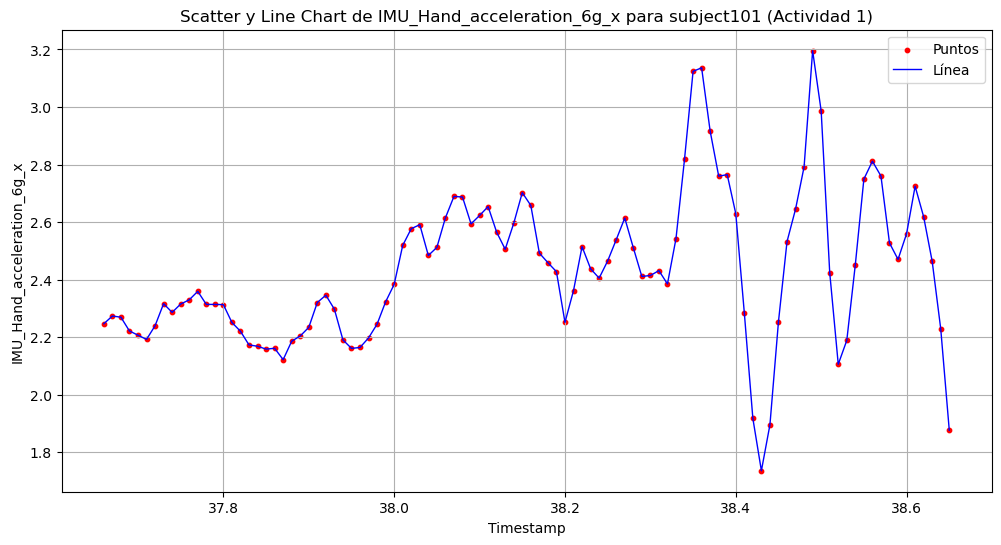

In [42]:
import matplotlib.pyplot as plt

# Filtrar el DataFrame para subject101 y actividad 1, limitando a 1000 ejemplos
subject101_activity1_data = pamap_data[
    (pamap_data["subject_id"] == "subject101") & 
    (pamap_data["activityID"] == 1)
].head(100)

# Extraer timestamp e IMU_Hand_acceleration_6g_x
timestamps = subject101_activity1_data["timestamp"]
acceleration_x = subject101_activity1_data["IMU_Hand_acceleration_6g_x"]

plt.figure(figsize=(12, 6))
# Graficar los puntos (scatter) en rojo
plt.scatter(timestamps, acceleration_x, color='red', s=10, label="Puntos")
# Superponer la línea en azul que une los puntos
plt.plot(timestamps, acceleration_x, color='blue', linestyle='-', linewidth=1, label="Línea")

plt.title("Scatter y Line Chart de IMU_Hand_acceleration_6g_x para subject101 (Actividad 1)")
plt.xlabel("Timestamp")
plt.ylabel("IMU_Hand_acceleration_6g_x")
plt.grid(True)
plt.legend()
plt.show()


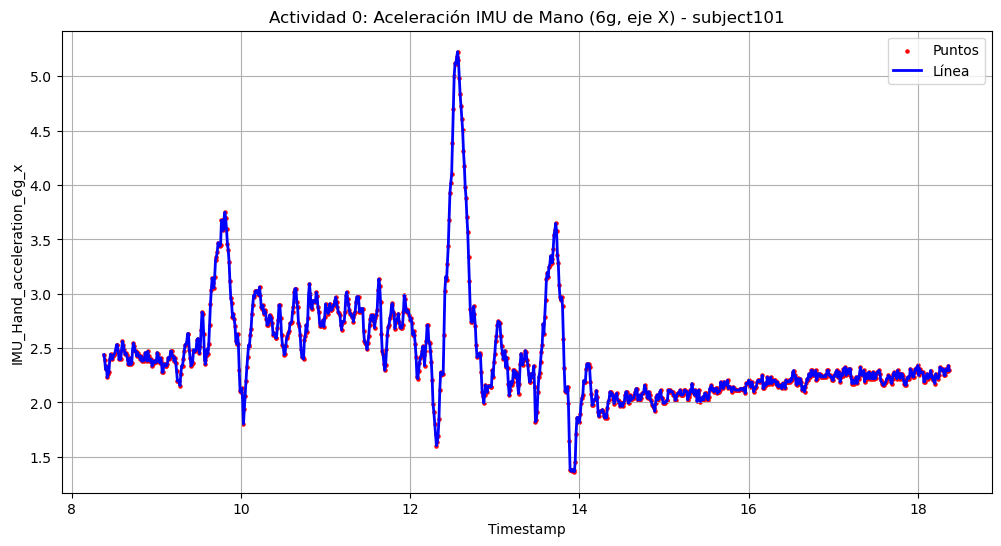

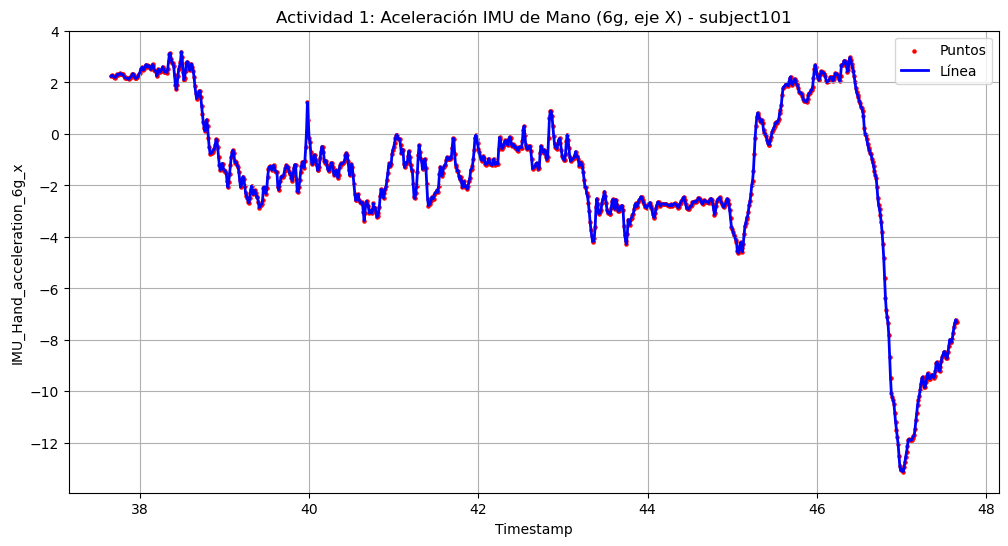

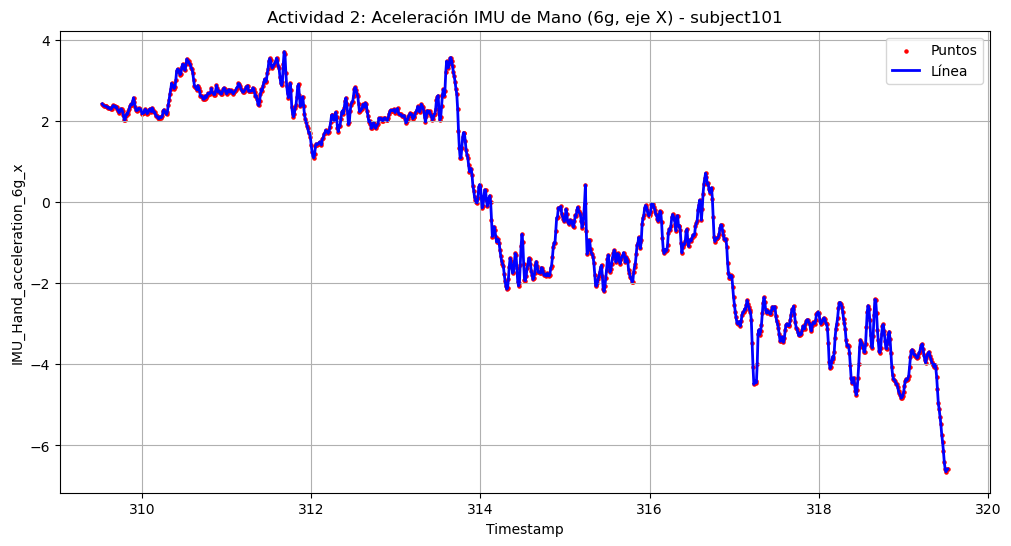

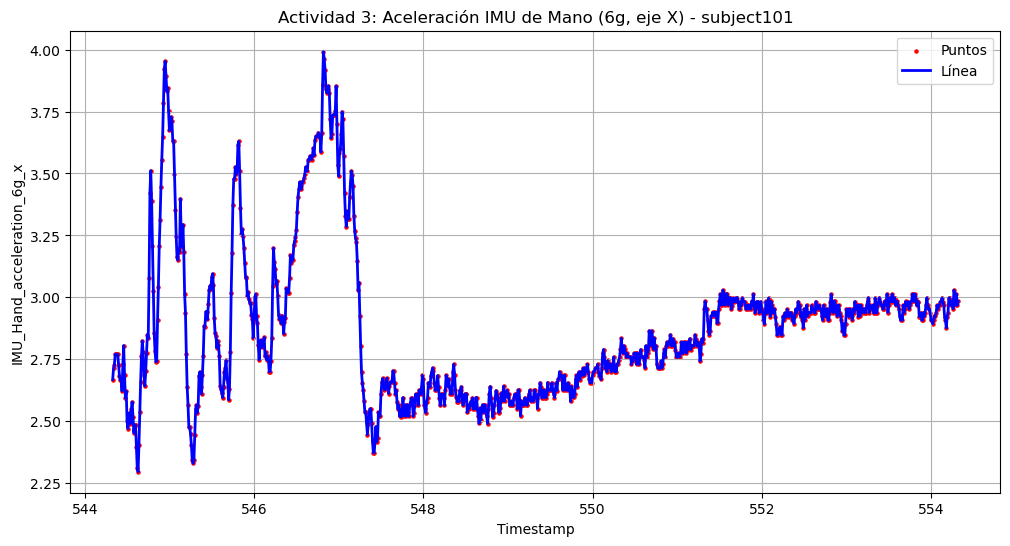

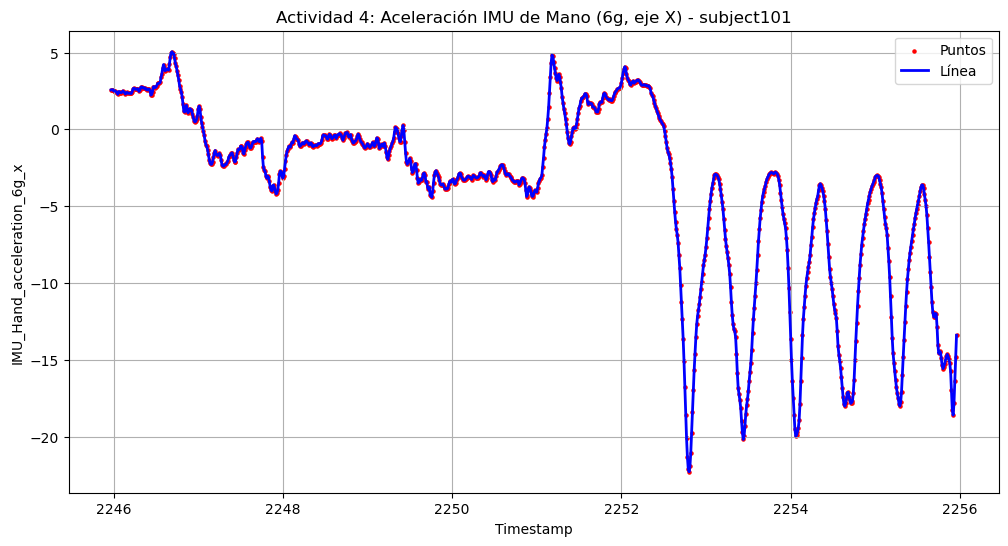

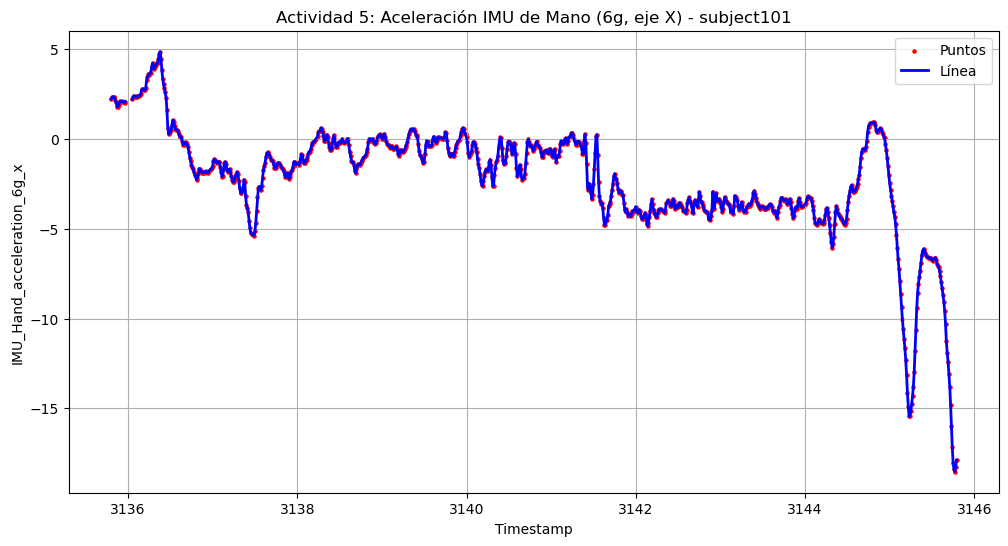

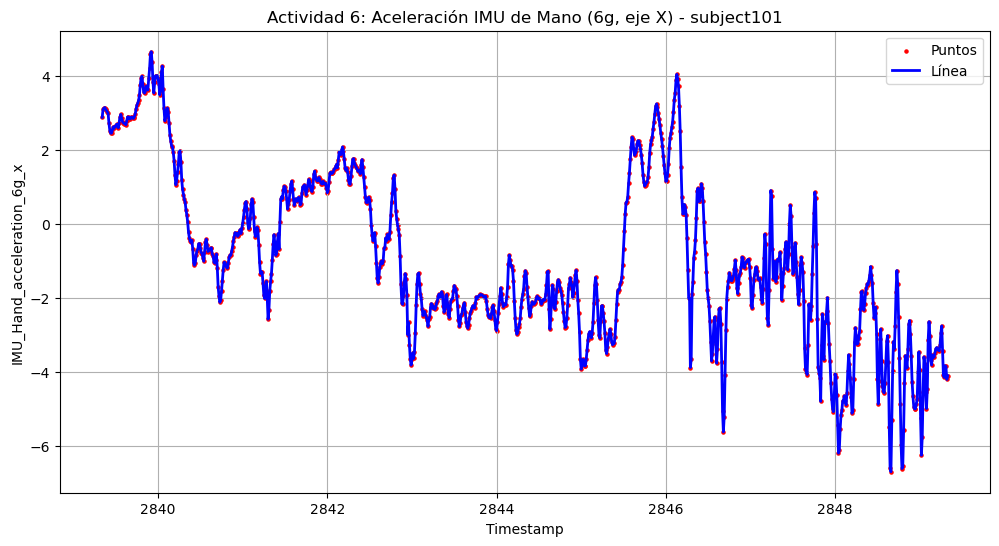

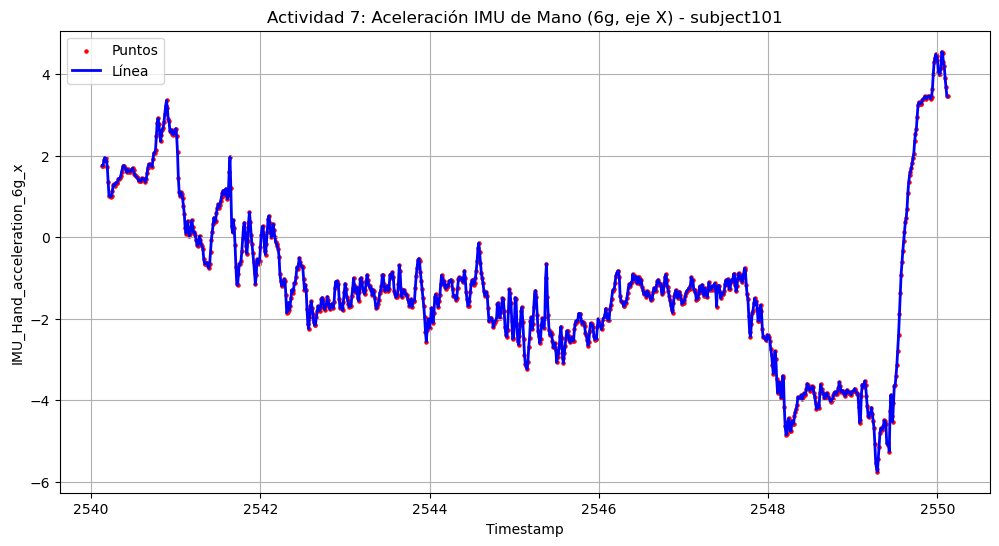

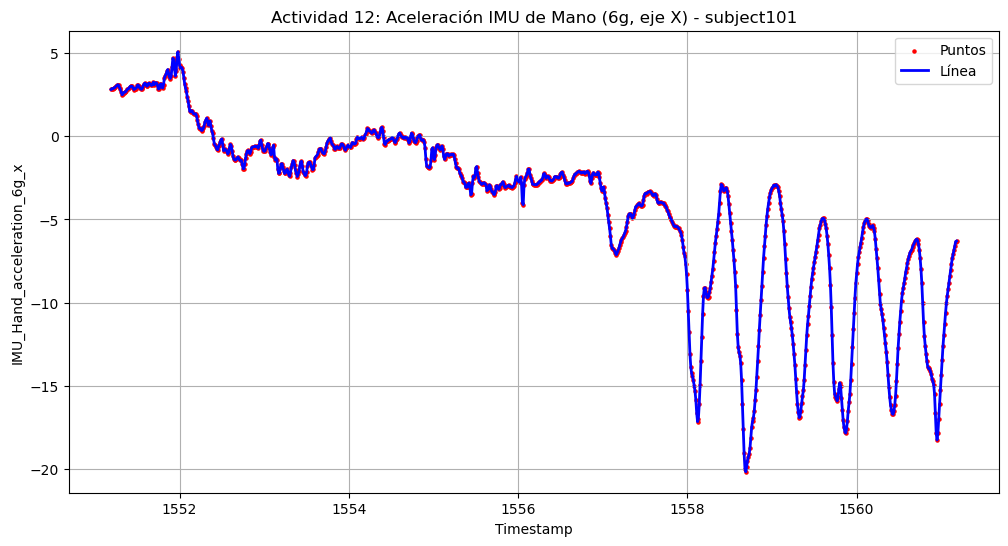

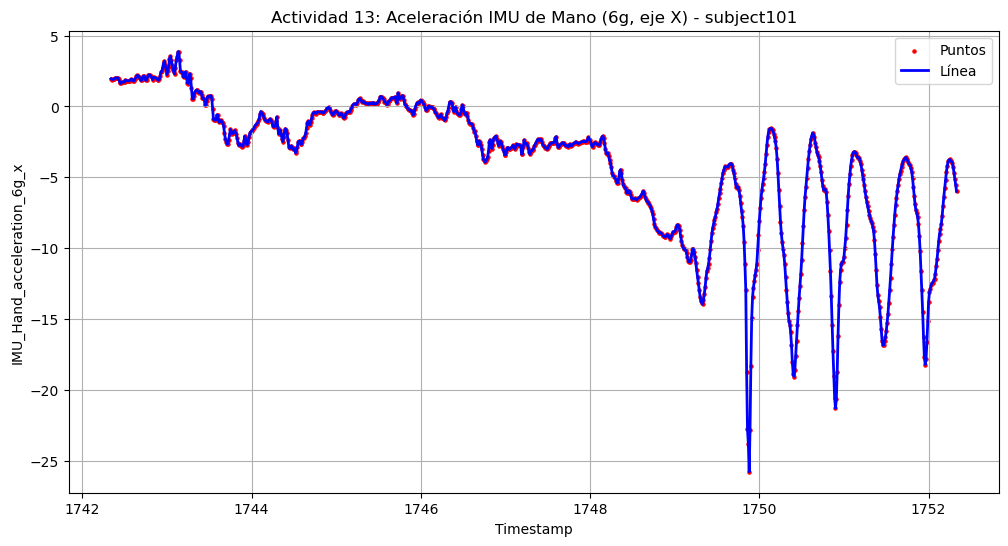

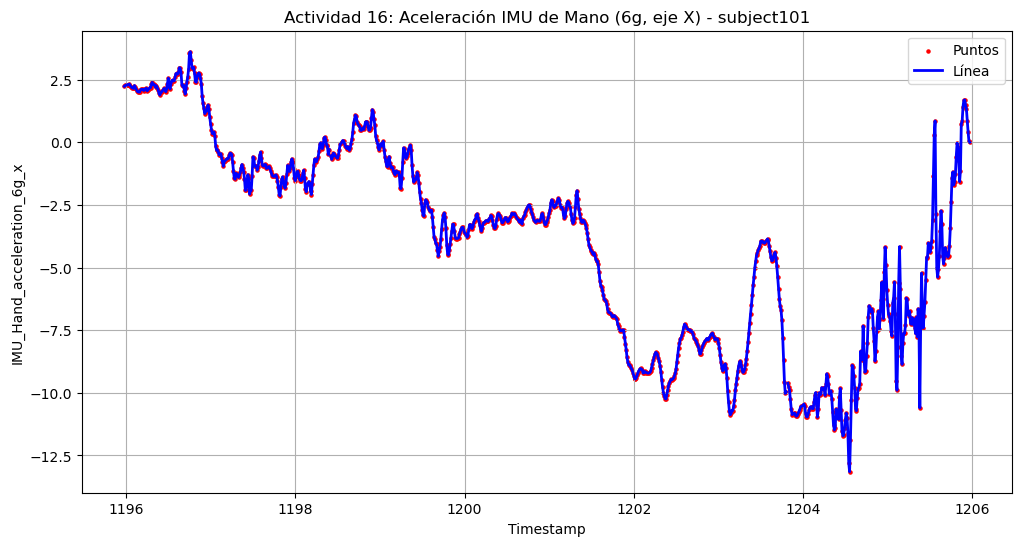

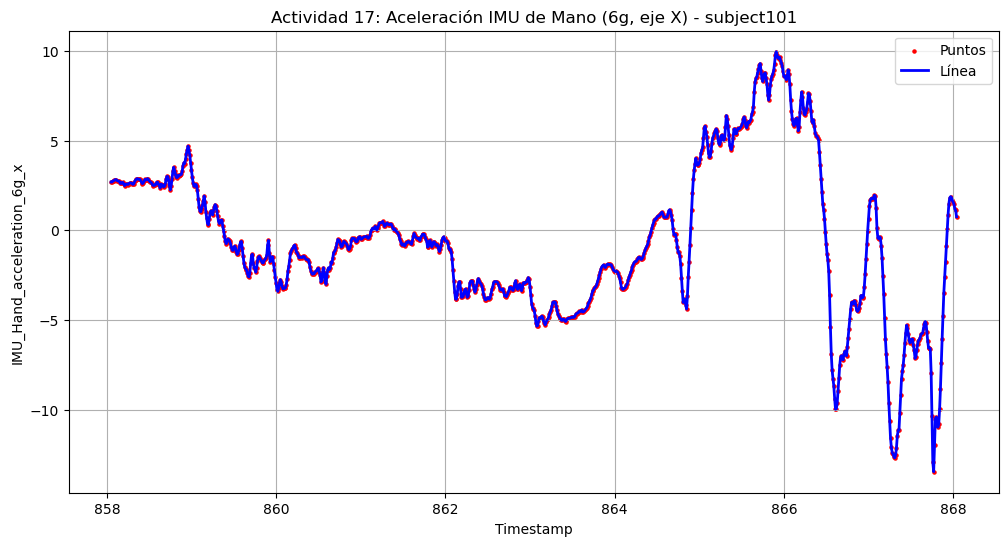

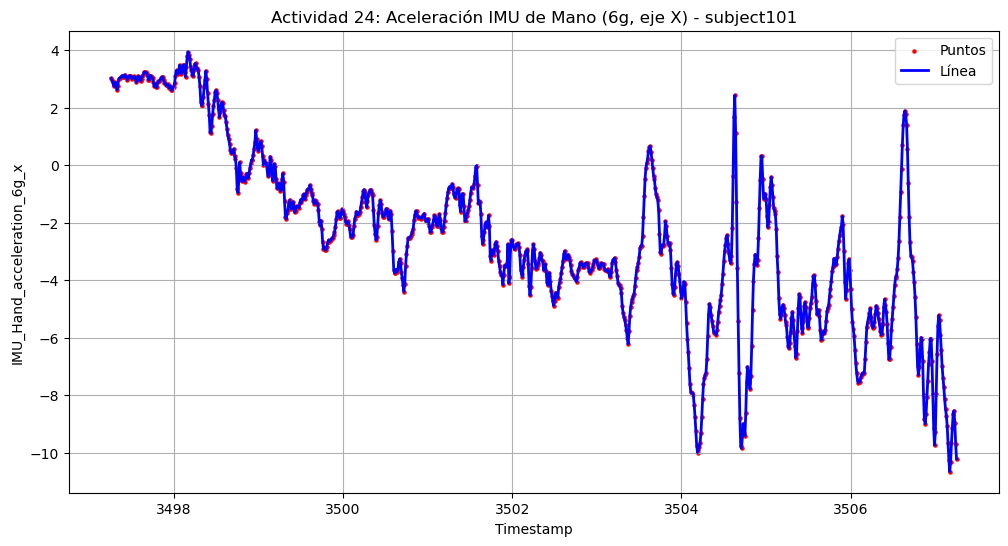

In [76]:
import matplotlib.pyplot as plt

# Lista de actividades
actividades = [0, 1, 2, 3, 4, 5, 6, 7, 12, 13, 16, 17, 24]

# Generar una gráfica por cada actividad, solo para IMU_Hand_acceleration_6g_x
for actividad in actividades:
    # Filtrar el DataFrame para subject101 y la actividad actual
    datos_filtrados = pamap_data[
        (pamap_data["subject_id"] == "subject101") & 
        (pamap_data["activityID"] == actividad)
    ].head(1000)  # Limitamos a 1000 registros para no sobrecargar la gráfica

    # Verificar que existan datos para la actividad
    if datos_filtrados.empty:
        continue

    # Extraer timestamp y la aceleración en el eje X
    timestamps = datos_filtrados["timestamp"]
    aceleracion_x = datos_filtrados["IMU_Hand_acceleration_6g_x"]

    # Crear la figura
    plt.figure(figsize=(12, 6))
    # Graficar los puntos (scatter) en rojo, pequeños pero visibles
    plt.scatter(timestamps, aceleracion_x, color='red', s=5, label="Puntos")
    # Superponer la línea en azul
    plt.plot(timestamps, aceleracion_x, color='blue', linewidth=2, label="Línea")
    
    # Cambiamos el título para que se entienda claramente el sensor graficado
    plt.title(f"Actividad {actividad}: Aceleración IMU de Mano (6g, eje X) - subject101")
    plt.xlabel("Timestamp")
    plt.ylabel("IMU_Hand_acceleration_6g_x")
    plt.grid(True)
    plt.legend()
    plt.show()


In [78]:
import pandas as pd
import numpy as np

# Definir el tamaño del grupo
batch_size = 3000

# Extraer los datos del acelerómetro que queremos analizar
acelerometro_x = pamap_data["IMU_Hand_acceleration_6g_x"]

# Dividir los datos en grupos de batch_size y calcular estadísticas
num_batches = len(acelerometro_x) // batch_size
stats = []

for i in range(num_batches):
    batch = acelerometro_x[i * batch_size:(i + 1) * batch_size]
    stats.append([
        i + 1,  # Índice del batch
        np.mean(batch),
        np.std(batch),
        np.min(batch),
        np.max(batch)
    ])

# Crear un DataFrame con los resultados
stats_df = pd.DataFrame(stats, columns=["Batch", "Mean", "Std. Deviation", "Min", "Max"])

# Mostrar la tabla
stats_df

,Batch,Mean,Std. Deviation,Min,Max
0,1,2.246,0.547,0.187,5.226
1,2,1.301,4.298,-14.051,6.834
2,3,6.085,0.062,5.926,6.300
3,4,2.267,2.609,-0.754,6.953
4,5,1.103,1.515,-2.177,8.487
...,...,...,...,...,...
952,953,-10.562,3.176,-20.388,-2.673
953,954,-9.693,2.939,-22.611,1.187
954,955,-9.746,3.926,-61.136,13.718
955,956,-3.329,5.575,-28.562,15.770


# Analyzing the batch statistics

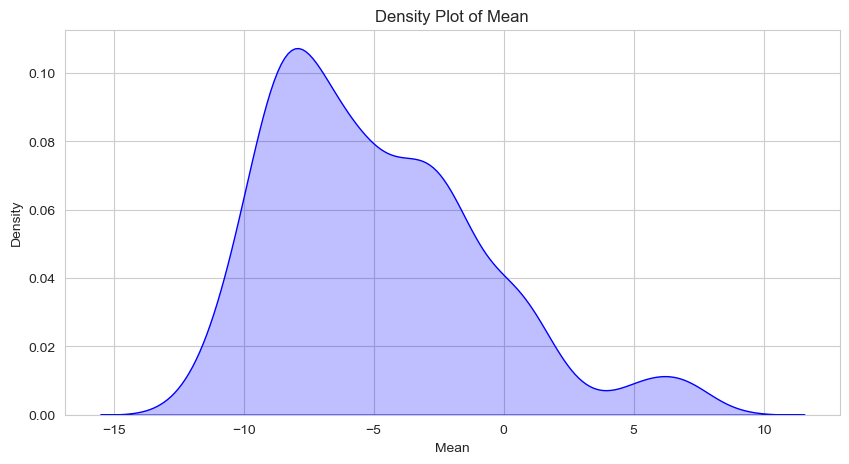

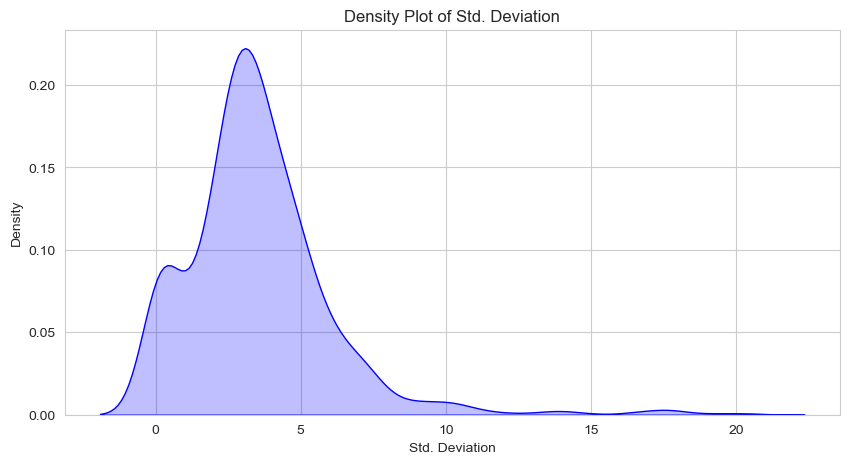

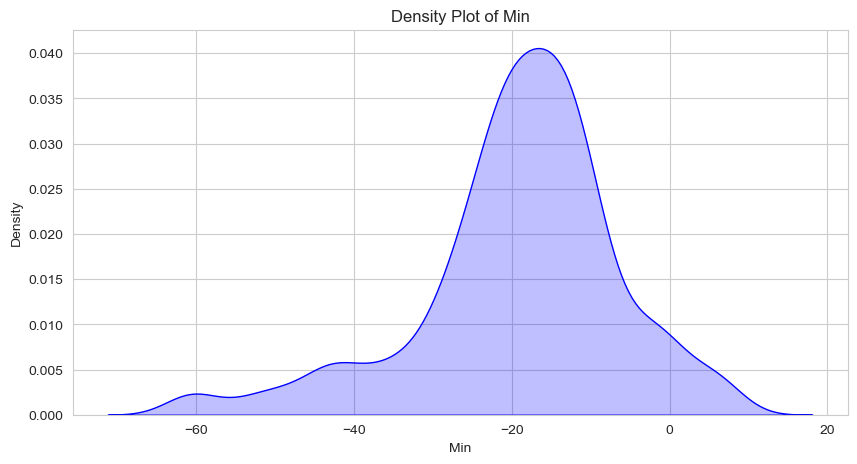

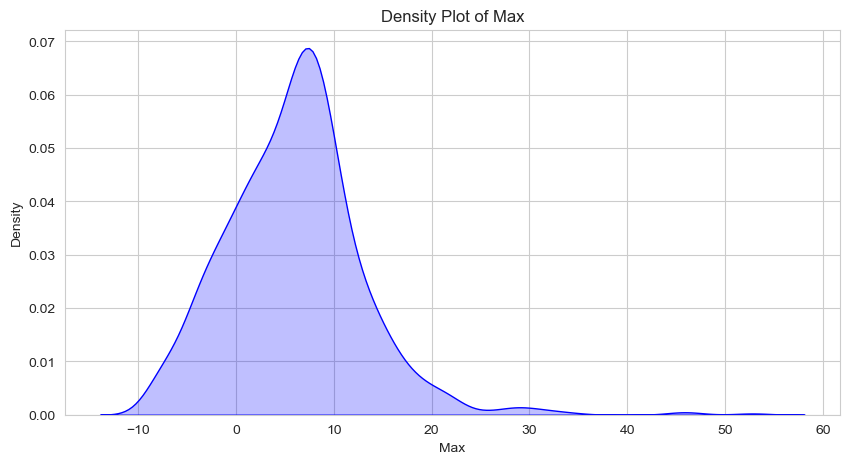

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns

# Function to create a density plot for a given statistic
def plot_density(data, stat_label):
    plt.figure(figsize=(10, 5))
    sns.kdeplot(data, fill=True, color="blue")
    plt.title(f"Density Plot of {stat_label}")
    plt.xlabel(stat_label)
    plt.ylabel("Density")
    plt.grid(True)
    plt.show()

# Function to create a boxplot for a given statistic
def plot_box(data, stat_label):
    plt.figure(figsize=(6, 5))
    sns.boxplot(x=data, color="lightgreen")
    plt.title(f"Boxplot of {stat_label}")
    plt.xlabel(stat_label)
    plt.grid(True)
    plt.show()

# Plot for 'Mean'
plot_density(stats_df["Mean"], "Mean")

# Plot for 'Std. Deviation'
plot_density(stats_df["Std. Deviation"], "Std. Deviation")

# Plot for 'Min'
plot_density(stats_df["Min"], "Min")

# Plot for 'Max'
plot_density(stats_df["Max"], "Max")


## Analizamos si hay variación significativa